In [47]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [48]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import os
import cv2
import re
from PIL import Image
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# QUESTION 2

In [49]:
training_data_path = "/content/gdrive/MyDrive/Data/emotion_classification/train"
testing_data_path = "/content/gdrive/MyDrive/Data/emotion_classification/test"

In [50]:
def retrieve_image_data(directory_path):

    image_collection = []
    labels = []
    for filename in os.listdir(directory_path):
        file_path = os.path.join(directory_path, filename)
        if "sad" in filename:
            labels.append(0)
        else:
            labels.append(1)
        image = Image.open(file_path).convert("L")
        image_array = np.array(image)
        if image_array is not None:
            image_collection.append(image_array.flatten())
    return np.array(image_collection), np.array(labels)

In [51]:
X_training, y_training = retrieve_image_data(training_data_path)
X_testing, y_testing = retrieve_image_data(testing_data_path)

In [52]:
def apply_pca_transformation(data, num_components):
    mean_vector = np.mean(data, axis=0)
    centered_data = data - mean_vector
    covariance_matrix = np.cov(centered_data.T)
    eigenvalues, eigenvectors = np.linalg.eigh(covariance_matrix)
    sorted_indices = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[sorted_indices]
    eigenvectors = eigenvectors[:, sorted_indices]
    top_eigenvectors = eigenvectors[:, :num_components]
    transformed_data = np.dot(centered_data, top_eigenvectors)

    return transformed_data, mean_vector, top_eigenvectors

In [10]:
print(f"Training Images Shape: {X_training.shape}")

Training Images Shape: (20, 10201)


In [11]:
print(f"Training Labels Shape: {y_training.shape}")

Training Labels Shape: (20,)


In [12]:
print(f"Testing Images Shape: {X_testing.shape}")

Testing Images Shape: (10, 10201)


In [13]:
print(f"Testing Labels Shape: {y_testing.shape}")


Testing Labels Shape: (10,)


In [18]:
# Parameters
pca_components = [2, 5, 10, 15, 20]
regularization_values = [0.1, 1.0, 10.0, 100.0]
tolerance_values = [0.1, 0.01, 0.001]
kernel_types = ['linear', 'rbf', 'poly', 'sigmoid']

In [19]:
experiment_results = []

In [20]:
# Iterate through different parameter combinations
for num_components in pca_components:
    print(f"Processing with {num_components} PCA components")

    # Apply PCA transformation
    X_train_pca, mean_vector, eigenvectors = apply_pca_transformation(X_training, num_components)
    X_test_pca = np.dot(X_testing - mean_vector, eigenvectors)

    for kernel_type in kernel_types:
        for regularization in regularization_values:
            for tolerance in tolerance_values:

                #train SVM model
                svm_model = SVC(kernel=kernel_type, C=regularization, tol=tolerance)
                svm_model.fit(X_train_pca, y_training)
                predictions = svm_model.predict(X_test_pca)
                accuracy = accuracy_score(y_testing, predictions)

                experiment_results.append({
                    'PCA Components': num_components,
                    'Kernel Type': kernel_type,
                    'Regularization': regularization,
                    'Tolerance': tolerance,
                    'Accuracy': accuracy
                })


Processing with 2 PCA components
Processing with 5 PCA components
Processing with 10 PCA components
Processing with 15 PCA components
Processing with 20 PCA components


In [21]:
df_experiment_results = pd.DataFrame(experiment_results)
df_experiment_results.to_csv("experiment_results.csv", index=False)

In [22]:
print("Results saved as experiment_results.csv")

Results saved as experiment_results.csv


In [23]:
results_df = pd.read_csv("experiment_results.csv")

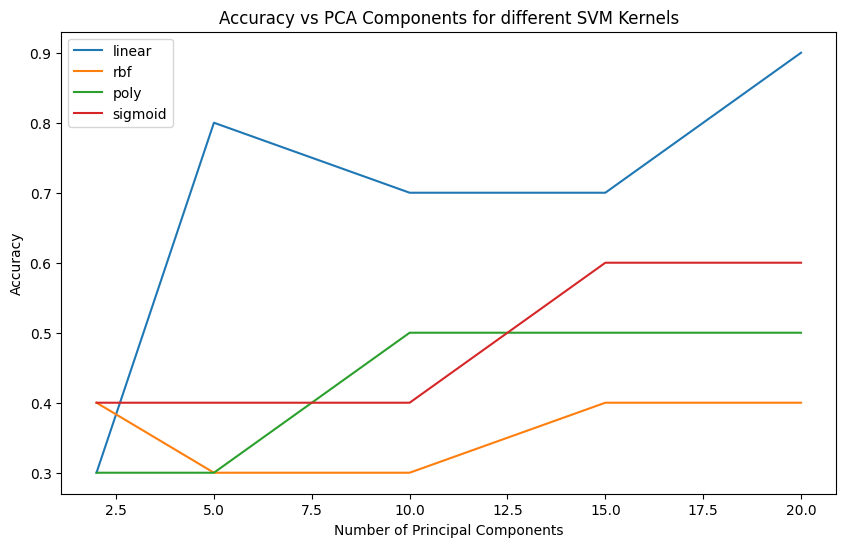

In [24]:
plt.figure(figsize=(10, 6))
for kernel_type in kernel_types:
    subset = results_df[(results_df['Kernel Type'] == kernel_type) & (results_df['Regularization'] == 1.0) & (results_df['Tolerance'] == 0.1)]
    plt.plot(subset['PCA Components'], subset['Accuracy'], label=kernel_type)
plt.xlabel("Number of Principal Components")
plt.ylabel("Accuracy")
plt.title("Accuracy vs PCA Components for different SVM Kernels")
plt.legend()
plt.show()

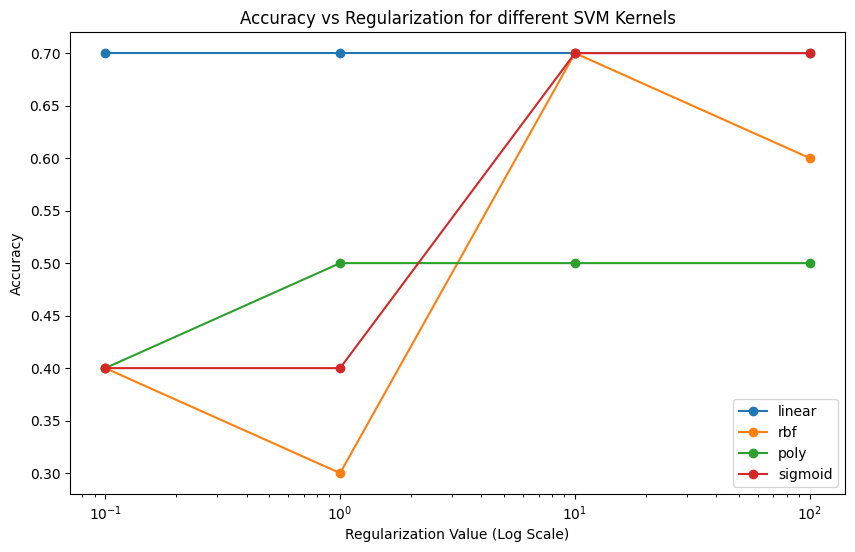

In [25]:
plt.figure(figsize=(10, 6))
for kernel_type in kernel_types:
    subset = results_df[(results_df['Kernel Type'] == kernel_type) & (results_df['PCA Components'] == 10) & (results_df['Tolerance'] == 0.1)]
    plt.plot(subset['Regularization'], subset['Accuracy'], marker='o', label=kernel_type)
plt.xscale('log')
plt.xlabel("Regularization Value (Log Scale)")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Regularization for different SVM Kernels")
plt.legend()
plt.show()

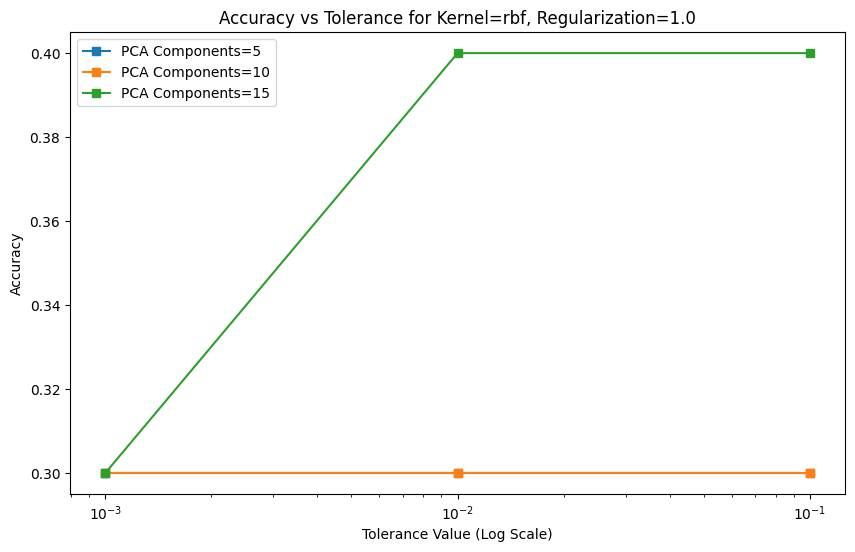

In [26]:
plt.figure(figsize=(10, 6))
fixed_kernel = 'rbf'
fixed_regularization = 1.0
for num_components in [5, 10, 15]:
    subset = results_df[(results_df['Kernel Type'] == fixed_kernel) & (results_df['PCA Components'] == num_components) & (results_df['Regularization'] == fixed_regularization)]
    plt.plot(subset['Tolerance'], subset['Accuracy'], marker='s', label=f'PCA Components={num_components}')
plt.xscale('log')
plt.xlabel("Tolerance Value (Log Scale)")
plt.ylabel("Accuracy")
plt.title(f"Accuracy vs Tolerance for Kernel={fixed_kernel}, Regularization={fixed_regularization}")
plt.legend()
plt.show()

In [27]:
best_index = results_df['Accuracy'].idxmax()
best_result = results_df.loc[best_index]

In [28]:
print(f"\nBest Performance:")
print(f"Accuracy: {best_result['Accuracy']:.4f}")
print(f"Parameters: PCA Components={best_result['PCA Components']}, Kernel Type={best_result['Kernel Type']}, Regularization={best_result['Regularization']}, Tolerance={best_result['Tolerance']}")



Best Performance:
Accuracy: 0.9000
Parameters: PCA Components=5, Kernel Type=linear, Regularization=0.1, Tolerance=0.1


**Applies Linear Discriminant Analysis (LDA) to find the best discriminant vector.**

In [29]:
def linear_discriminant_analysis(X, y):
    class1_data = X[y == 1]
    class2_data = X[y == 0]

    class1_mean = np.mean(class1_data, axis=0, keepdims=True)
    class2_mean = np.mean(class2_data, axis=0, keepdims=True)

    between_class_scatter = np.matmul((class1_mean - class2_mean).T, (class1_mean - class2_mean))

    within_class_scatter = np.matmul((class1_data - class1_mean).T, (class1_data - class1_mean)) + \
                           np.matmul((class2_data - class2_mean).T, (class2_data - class2_mean))

    eigenvalues, eigenvectors = np.linalg.eig(np.linalg.inv(within_class_scatter).dot(between_class_scatter))
    sorted_indices = np.argsort(eigenvalues)[::-1]
    discriminant_vector = eigenvectors[:, sorted_indices[0]]

    return discriminant_vector.real

In [30]:
pca_dimensions = [2, 5, 10, 15, 20]
evaluation_results = []


Processing for PCA Dimension=2


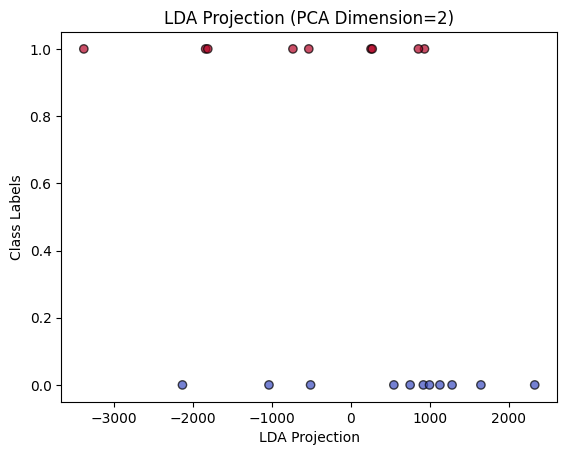

Accuracy for PCA Dimension=2: 50.00%

Processing for PCA Dimension=5


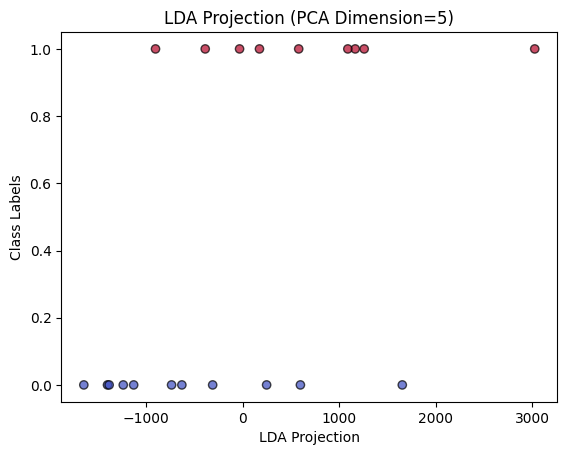

Accuracy for PCA Dimension=5: 50.00%

Processing for PCA Dimension=10


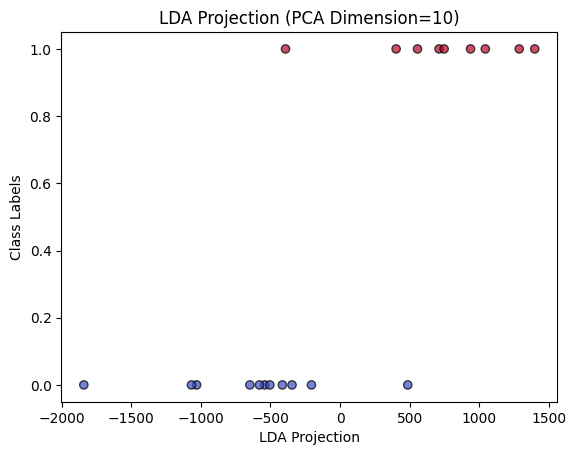

Accuracy for PCA Dimension=10: 90.00%

Processing for PCA Dimension=15


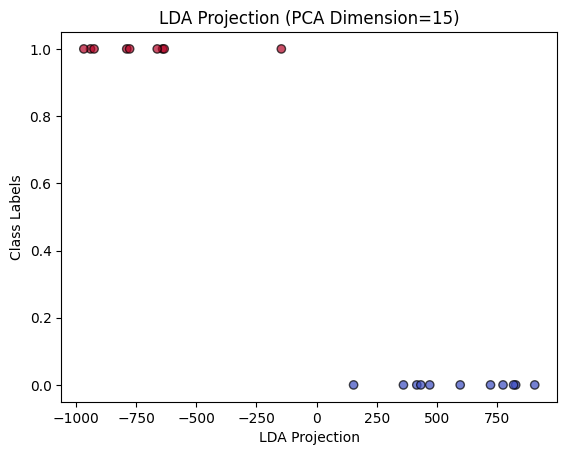

Accuracy for PCA Dimension=15: 90.00%

Processing for PCA Dimension=20


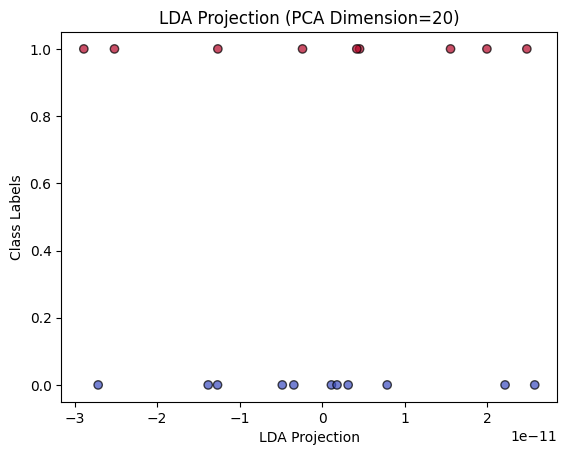

Accuracy for PCA Dimension=20: 40.00%


In [31]:
for dimension in pca_dimensions:
    print(f"\nProcessing for PCA Dimension={dimension}")

    X_training_pca, mean_vector, pca_vectors = apply_pca_transformation(X_training, dimension)

    lda_vector = linear_discriminant_analysis(X_training_pca, y_training)

    X_training_lda = np.dot(X_training_pca, lda_vector)

    X_testing_pca = np.dot(X_testing - mean_vector, pca_vectors)
    X_testing_lda = np.dot(X_testing_pca, lda_vector)

    threshold = (np.mean(X_training_lda[y_training == 0]) + np.mean(X_training_lda[y_training == 1])) / 2
    flag = threshold > np.mean(X_training_lda[y_training == 0])

    y_pred = np.array([1 if (val - threshold >= 0) == flag else 0 for val in X_testing_lda])

    accuracy = accuracy_score(y_testing, y_pred)
    evaluation_results.append({'PCA Dimension': dimension, 'accuracy': accuracy})

    # Plot LDA projection
    plt.scatter(X_training_lda.real, y_training, c=y_training, cmap='coolwarm', alpha=0.7, edgecolors='k')
    plt.xlabel("LDA Projection")
    plt.ylabel("Class Labels")
    plt.title(f"LDA Projection (PCA Dimension={dimension})")
    plt.show()

    print(f"Accuracy for PCA Dimension={dimension}: {accuracy:.2%}")


In [32]:
df_evaluation_results = pd.DataFrame(evaluation_results)
df_evaluation_results.to_csv("evaluation_results.csv", index=False)
print("\nResults saved to 'evaluation_results.csv'")


Results saved to 'evaluation_results.csv'


**Performance of LDA and SVM is similar in accuracy arund 0.9
SVM tries to find best classfier line by increasing marging while LDA tries to find classfication plance according to
optimizing within cluster and between cluster variance of classes.
But similarity is both tries to find line which best classifies dataset but to classfiy them they use different strategies.**

# QUESTION 3

In [114]:
class Logistic_Regression:
    def __init__(self, param=1e-3, reg=False, lambdas=1e-2, total_iterations=1000, tol=1e-4):
        self.W = None
        self.b = None
        self.tol = tol
        self.total_iterations = total_iterations
        self.reg = reg
        self.param = param
        self.lambda_ = lambdas

    def sigm(self, x):
        return 1 / (1 + np.exp(-x))

    def c_entropy(self, x, true_value_of_y):
        N = x.shape[0]
        predicted_value_of_y = self.sigm(self.b + (x @ self.W)).reshape(-1, 1)
        d_err = -((np.log(1e-9 + predicted_value_of_y) * true_value_of_y) +
                  (np.log(1e-9 + 1 - predicted_value_of_y) * (1 - true_value_of_y))).sum() / N
        r_err = 0
        if self.reg:
            r_err = (self.W.T @ self.W)[0, 0] / (self.lambda_ * 2 * N)
        c_loss = d_err + r_err
        return c_loss

    def grad_w(self, x, true_value_of_y):
        N = x.shape[0]
        predicted_value_of_y = self.sigm(self.b + (x @ self.W)).reshape(-1, 1)
        diff = predicted_value_of_y - true_value_of_y
        d_w = np.sum(x * diff, axis=0).reshape(-1, 1)
        reg = 0
        if self.reg:
            reg = self.W / (self.lambda_ * N)
        d_w -= reg
        return d_w

    def grad_b(self, x, true_value_of_y):
        N = x.shape[0]
        predicted_value_of_y = self.sigm((x @ self.W) + self.b).reshape(-1, 1)
        diff = predicted_value_of_y - true_value_of_y
        d_b = np.sum(diff)
        return d_b

    def predict(self, x):
        predicted_value_of_y_proba = self.sigm((x @ self.W) + self.b).reshape(-1, 1)
        return ((predicted_value_of_y_proba >= 0.5).astype(np.int32).reshape(-1, 1))

    def get_accuracy(self, predicted_value_of_y, true_value_of_y):
        return np.sum(predicted_value_of_y == true_value_of_y) / true_value_of_y.shape[0]

    def fit(self, x, y, batch_size=32):
        self.W = np.ones((x.shape[1], 1))
        self.b = 1
        x_tr, x_val, y_tr, y_val = train_test_split(x, y, test_size=1/6, random_state=59)
        N = x_tr.shape[0]
        num_batch = N // batch_size

        self.train_loss = []
        self.val_loss = []

        for epoch in range(self.total_iterations):
            for i in range(num_batch):
                left = i * batch_size
                right = (i + 1) * batch_size

                x_train_batch, y_train_batch = x_tr[left:right], y_tr[left:right]

                d_w = self.grad_w(x_train_batch, y_train_batch).reshape(-1, 1)
                d_b = self.grad_b(x_train_batch, y_train_batch)

                if self.tol > np.linalg.norm(d_w):
                    break

                self.W -= (self.param * d_w)
                self.b -= (self.param * d_b)

            train_loss_epoch = self.c_entropy(x_tr, y_tr)
            val_loss_epoch = self.c_entropy(x_val, y_val)
            self.train_loss.append(train_loss_epoch)
            self.val_loss.append(val_loss_epoch)

            y_tr_pred, y_val_pred = self.predict(x_tr), self.predict(x_val)
            train_acc_epoch = np.mean(y_tr == y_tr_pred)
            val_acc_epoch = np.mean(y_val == y_val_pred)

            if (epoch + 1) % 4 == 0:
                print(f"Epoch {epoch+1}: Training Accuracy={train_acc_epoch:.4f}, Validation Accuracy={val_acc_epoch:.4f}")

        # Plot loss curves
        plt.figure()
        plt.title("Loss Curve")
        plt.plot(self.train_loss, label='Training Loss')
        plt.plot(self.val_loss, label='Validation Loss')
        plt.xlabel("Epochs")
        plt.ylabel("Cross-Entropy Loss")
        plt.legend()
        plt.show()


## Part (a): Splitting the data into subsets

In [115]:
data_dir = "/content/gdrive/MyDrive/movieReviews1000.txt"
file = open(data_dir, 'r')
lines = file.readlines()

In [116]:
# Preprocess data
texts = []
labels = []
for line in lines:
    line = re.sub(':|;', ' ', line)
    line = re.sub('/|-', ' ', line)
    words = line.split()
    label = int(words[-1])
    text = ' '.join(words[:-1])
    texts.append(text.lower())
    labels.append(label)

labels = np.array(labels).reshape(-1, 1)

In [117]:
# Convert text data to TF-IDF features
tf_idf = TfidfVectorizer()
features = tf_idf.fit_transform(texts).toarray()

In [118]:
# Split into training and testing subsets
train_a, test_a = features[:900, :], features[900:, :]
train_b, test_b = labels[:900, :], labels[900:, :]

In [119]:
print("Training data shape:", train_a.shape)
print("Testing data shape:", test_a.shape)


Training data shape: (900, 3106)
Testing data shape: (100, 3106)


## Part (b): Using TF-IDF features and custom PCA

In [120]:
def apply_pca(input_data, num_features):
    mean_vector = np.mean(input_data, axis=0)
    centered_data = input_data - mean_vector
    covariance_matrix = np.cov(centered_data.T)
    eigenvalues, eigenvectors = np.linalg.eigh(covariance_matrix)
    sorted_indices = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[sorted_indices]
    eigenvectors = eigenvectors[:, sorted_indices]
    top_eigenvectors = eigenvectors[:, :num_features]
    transformed_data = np.dot(centered_data, top_eigenvectors)

    return transformed_data, mean_vector, top_eigenvectors

In [121]:
train_a_pca, mean_vector_train, pca_components_train = apply_pca(train_a, num_features=30)
centered_test_a = test_a - mean_vector_train
test_a_pca = np.dot(centered_test_a, pca_components_train)

In [122]:
print("Training data after PCA shape:", train_a_pca.shape)
print("Testing data after PCA shape:", test_a_pca.shape)

Training data after PCA shape: (900, 30)
Testing data after PCA shape: (100, 30)


## Part (c): Logistic regression with stochastic gradient descent

In [123]:
# Split training data
x_train, x_val, y_train, y_val = train_test_split(train_a_pca, train_b, test_size=90/900, random_state=42)

In [124]:
results_summary = []
batch_sizes = [32, 64, 128]
learning_rates = [1e-3, 1e-2, 1e-1]


Training with batch size=32, learning rate=0.001
Epoch 4: Training Accuracy=0.5200, Validation Accuracy=0.4741
Epoch 8: Training Accuracy=0.5481, Validation Accuracy=0.5111
Epoch 12: Training Accuracy=0.5496, Validation Accuracy=0.5481
Epoch 16: Training Accuracy=0.5615, Validation Accuracy=0.5556
Epoch 20: Training Accuracy=0.5600, Validation Accuracy=0.5556


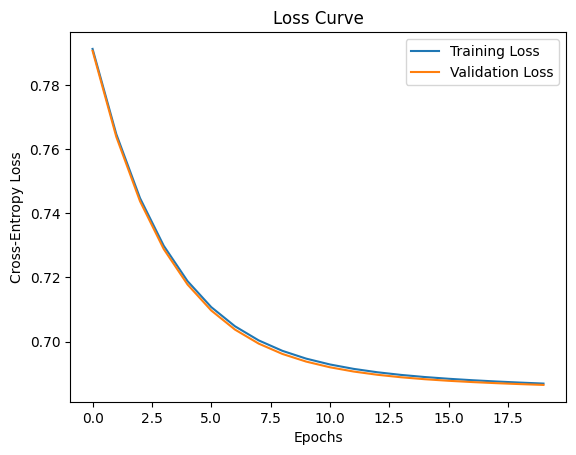

Validation Accuracy: 0.5778
Test Accuracy: 0.5200

Training with batch size=32, learning rate=0.01
Epoch 4: Training Accuracy=0.5556, Validation Accuracy=0.5926
Epoch 8: Training Accuracy=0.5719, Validation Accuracy=0.6074
Epoch 12: Training Accuracy=0.5837, Validation Accuracy=0.6296
Epoch 16: Training Accuracy=0.5926, Validation Accuracy=0.6370
Epoch 20: Training Accuracy=0.6030, Validation Accuracy=0.6667


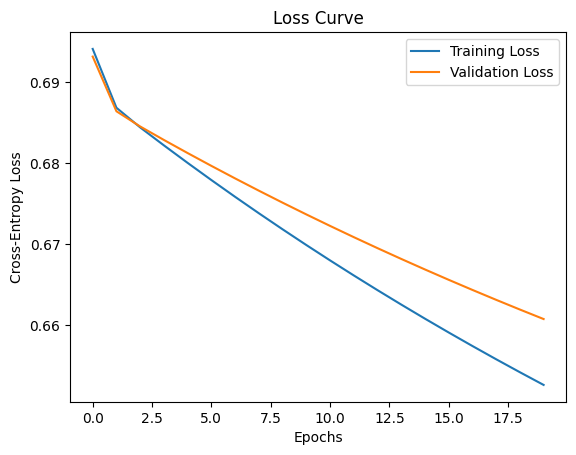

Validation Accuracy: 0.5222
Test Accuracy: 0.6100

Training with batch size=32, learning rate=0.1
Epoch 4: Training Accuracy=0.6622, Validation Accuracy=0.6444
Epoch 8: Training Accuracy=0.6830, Validation Accuracy=0.6667
Epoch 12: Training Accuracy=0.6993, Validation Accuracy=0.6815
Epoch 16: Training Accuracy=0.6963, Validation Accuracy=0.6741
Epoch 20: Training Accuracy=0.6993, Validation Accuracy=0.6593


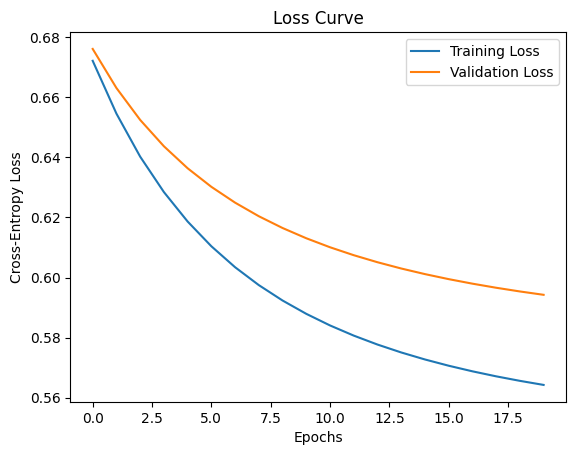

Validation Accuracy: 0.5889
Test Accuracy: 0.7600

Training with batch size=64, learning rate=0.001
Epoch 4: Training Accuracy=0.5170, Validation Accuracy=0.4741
Epoch 8: Training Accuracy=0.5393, Validation Accuracy=0.5111
Epoch 12: Training Accuracy=0.5496, Validation Accuracy=0.5407
Epoch 16: Training Accuracy=0.5615, Validation Accuracy=0.5407
Epoch 20: Training Accuracy=0.5570, Validation Accuracy=0.5630


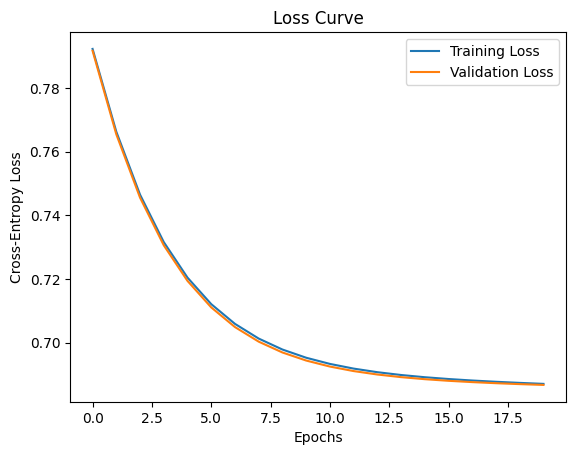

Validation Accuracy: 0.5778
Test Accuracy: 0.5200

Training with batch size=64, learning rate=0.01
Epoch 4: Training Accuracy=0.5570, Validation Accuracy=0.5926
Epoch 8: Training Accuracy=0.5704, Validation Accuracy=0.6074
Epoch 12: Training Accuracy=0.5763, Validation Accuracy=0.6148
Epoch 16: Training Accuracy=0.5911, Validation Accuracy=0.6370
Epoch 20: Training Accuracy=0.5985, Validation Accuracy=0.6370


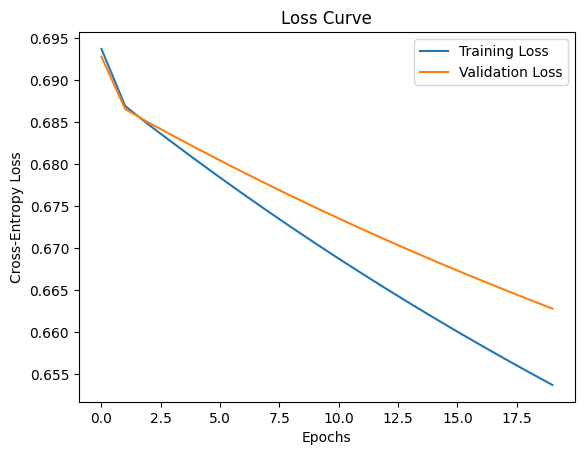

Validation Accuracy: 0.5111
Test Accuracy: 0.5800

Training with batch size=64, learning rate=0.1
Epoch 4: Training Accuracy=0.5911, Validation Accuracy=0.6222
Epoch 8: Training Accuracy=0.6267, Validation Accuracy=0.6889
Epoch 12: Training Accuracy=0.6593, Validation Accuracy=0.7185
Epoch 16: Training Accuracy=0.6681, Validation Accuracy=0.7259
Epoch 20: Training Accuracy=0.6800, Validation Accuracy=0.7185


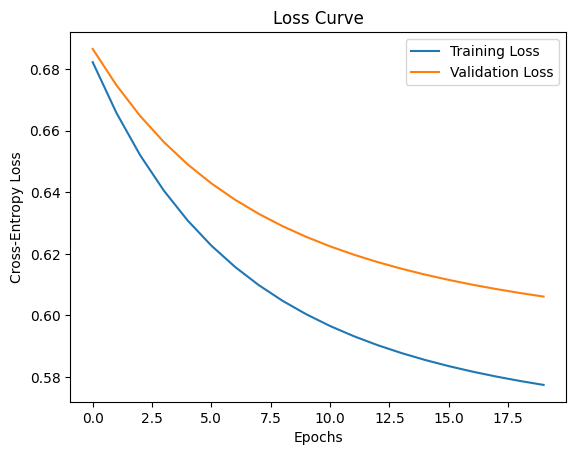

Validation Accuracy: 0.5667
Test Accuracy: 0.5800

Training with batch size=128, learning rate=0.001
Epoch 4: Training Accuracy=0.5185, Validation Accuracy=0.4741
Epoch 8: Training Accuracy=0.5407, Validation Accuracy=0.5111
Epoch 12: Training Accuracy=0.5526, Validation Accuracy=0.5481
Epoch 16: Training Accuracy=0.5630, Validation Accuracy=0.5481
Epoch 20: Training Accuracy=0.5585, Validation Accuracy=0.5630


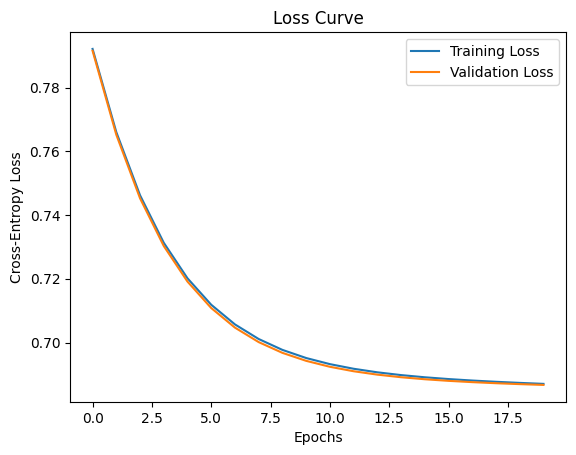

Validation Accuracy: 0.5778
Test Accuracy: 0.5200

Training with batch size=128, learning rate=0.01
Epoch 4: Training Accuracy=0.5585, Validation Accuracy=0.5926
Epoch 8: Training Accuracy=0.5719, Validation Accuracy=0.6074
Epoch 12: Training Accuracy=0.5748, Validation Accuracy=0.6222
Epoch 16: Training Accuracy=0.5926, Validation Accuracy=0.6296
Epoch 20: Training Accuracy=0.6044, Validation Accuracy=0.6519


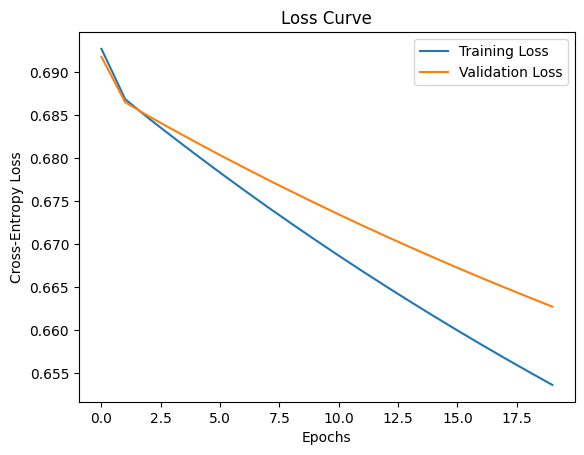

Validation Accuracy: 0.5000
Test Accuracy: 0.5900

Training with batch size=128, learning rate=0.1
Epoch 4: Training Accuracy=0.4830, Validation Accuracy=0.4667
Epoch 8: Training Accuracy=0.4963, Validation Accuracy=0.4963
Epoch 12: Training Accuracy=0.5141, Validation Accuracy=0.5037
Epoch 16: Training Accuracy=0.5407, Validation Accuracy=0.4963
Epoch 20: Training Accuracy=0.5659, Validation Accuracy=0.4963


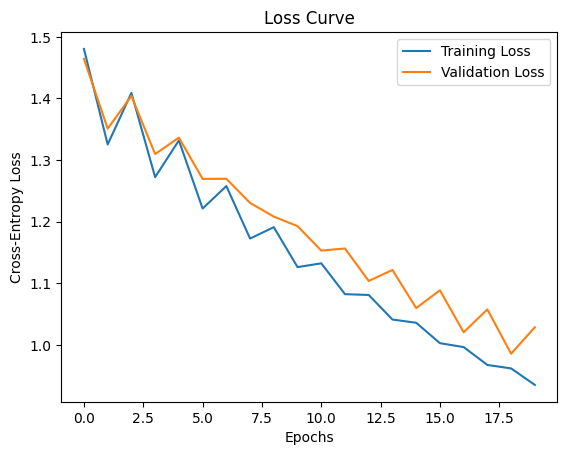

Validation Accuracy: 0.5556
Test Accuracy: 0.7400


In [125]:
for batch_size in batch_sizes:
    for lr in learning_rates:
        print(f"\nTraining with batch size={batch_size}, learning rate={lr}")
        model = Logistic_Regression(param=lr, reg=False, total_iterations=20)
        model.fit(x_train, y_train, batch_size=batch_size)

        val_predictions = model.predict(x_val)
        val_accuracy = model.get_accuracy(val_predictions, y_val)

        test_predictions = model.predict(test_a_pca)
        test_accuracy = model.get_accuracy(test_predictions, test_b)

        results_summary.append({
            "Batch Size": batch_size,
            "Learning Rate": lr,
            "Validation Accuracy": val_accuracy,
            "Test Accuracy": test_accuracy
        })

        print(f"Validation Accuracy: {val_accuracy:.4f}")
        print(f"Test Accuracy: {test_accuracy:.4f}")


## Part (d): Logistic regression with L2 regularization

In [126]:
regularization_values = [1e-2, 1e-1, 1.0]


Training with L2 regularization (lambda=0.01)
Epoch 4: Training Accuracy=0.5570, Validation Accuracy=0.5926
Epoch 8: Training Accuracy=0.5644, Validation Accuracy=0.6000
Epoch 12: Training Accuracy=0.5763, Validation Accuracy=0.6222
Epoch 16: Training Accuracy=0.5837, Validation Accuracy=0.6296
Epoch 20: Training Accuracy=0.5941, Validation Accuracy=0.6444


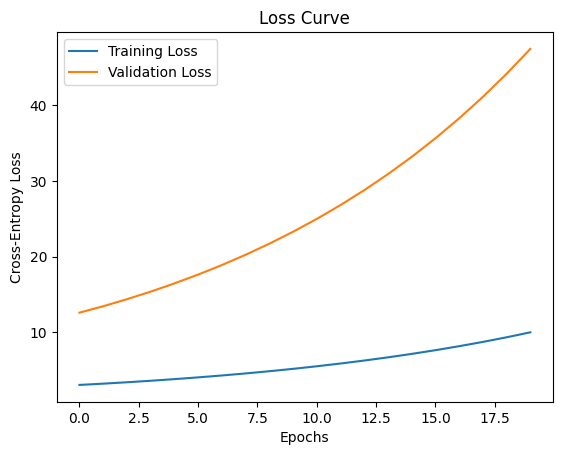

Validation Accuracy: 0.5222
Test Accuracy: 0.6000

Training with L2 regularization (lambda=0.1)
Epoch 4: Training Accuracy=0.5585, Validation Accuracy=0.5852
Epoch 8: Training Accuracy=0.5719, Validation Accuracy=0.6074
Epoch 12: Training Accuracy=0.5763, Validation Accuracy=0.6222
Epoch 16: Training Accuracy=0.5956, Validation Accuracy=0.6370
Epoch 20: Training Accuracy=0.5985, Validation Accuracy=0.6444


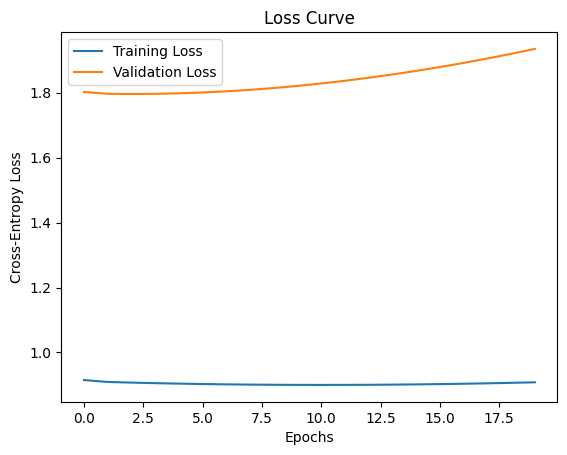

Validation Accuracy: 0.5111
Test Accuracy: 0.5900

Training with L2 regularization (lambda=1.0)
Epoch 4: Training Accuracy=0.5585, Validation Accuracy=0.5926
Epoch 8: Training Accuracy=0.5719, Validation Accuracy=0.6074
Epoch 12: Training Accuracy=0.5763, Validation Accuracy=0.6222
Epoch 16: Training Accuracy=0.5926, Validation Accuracy=0.6296
Epoch 20: Training Accuracy=0.6044, Validation Accuracy=0.6519


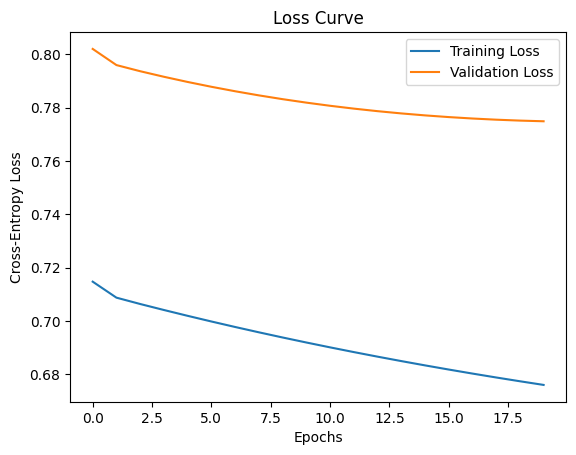

Validation Accuracy: 0.5000
Test Accuracy: 0.5900


In [128]:
for reg_value in regularization_values:
    print(f"\nTraining with L2 regularization (lambda={reg_value})")
    model = Logistic_Regression(param=1e-2, reg=True, lambdas=reg_value, total_iterations=20)
    model.fit(x_train, y_train, batch_size=128)

    val_predictions = model.predict(x_val)
    val_accuracy = model.get_accuracy(val_predictions, y_val)

    test_predictions = model.predict(test_a_pca)
    test_accuracy = model.get_accuracy(test_predictions, test_b)

    results_summary.append({
        "Regularization Coefficient": reg_value,
        "Validation Accuracy": val_accuracy,
        "Test Accuracy": test_accuracy
    })

    print(f"Validation Accuracy: {val_accuracy:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f}")


**Summarizing Results**

## Observations on Overfitting/Underfitting
For $\lambda = 0.01$, the model overfits as the training loss is low while the validation loss increases significantly.
For $\lambda = 0.1$, there is a balance between overfitting and underfitting, but performance is suboptimal.
For $\lambda = 1$, the model likely underfits as both losses remain high, and there is minimal improvement in accuracy.

## Performance on Test Set
The test accuracy remains relatively stable across all three regularization settings:

Test accuracy for $\lambda = 0.01$ is 60% (highest)

Test accuracy for $\lambda = 0.1$ is 59%

Test accuracy for $\lambda = 1$ is 59%

In conclusion, while $\lambda = 0.01$ suffers from overfitting and $\lambda = 1$ from underfitting, $\lambda = 0.1$ provides a reasonable trade-off between these issues, achieving the highest test accuracy.

# QUESTION 6

In [14]:
class CustomNeuralNetworkModel:
    def __init__(self, input_features, hidden_features, output_features):
        # Initialize weights and biases for neural layers
        self.first_layer_weights = np.random.randn(input_features, hidden_features) * 0.01
        self.first_layer_bias = np.zeros((1, hidden_features))
        self.second_layer_weights = np.random.randn(hidden_features, output_features) * 0.01
        self.second_layer_bias = np.zeros((1, output_features))

    def activation_function_relu(self, x):
        return np.maximum(0, x)

    def derivative_relu(self, x):
        return (x > 0).astype(float)

    def activation_function_softmax(self, x):
        exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
        return exp_x / np.sum(exp_x, axis=1, keepdims=True)

    def forward_propagation(self, input_data):
        self.hidden_layer_input_values = np.dot(input_data, self.first_layer_weights) + self.first_layer_bias
        self.hidden_layer_output_values = self.activation_function_relu(self.hidden_layer_input_values)

        self.output_layer_input_values = np.dot(self.hidden_layer_output_values, self.second_layer_weights) + self.second_layer_bias
        self.output_layer_output_values = self.activation_function_softmax(self.output_layer_input_values)

        return self.output_layer_output_values

    def backward_propagation(self, input_data, target_labels, learning_rate=0.0025):
        num_samples = input_data.shape[0]

        self.forward_propagation(input_data)

        one_hot_target_labels = np.zeros((num_samples, 2))
        one_hot_target_labels[np.arange(num_samples), target_labels] = 1

        output_error = self.output_layer_output_values - one_hot_target_labels
        gradient_second_layer_weights = (1 / num_samples) * np.dot(self.hidden_layer_output_values.T, output_error)
        gradient_second_layer_bias = (1 / num_samples) * np.sum(output_error, axis=0, keepdims=True)

        hidden_error = np.dot(output_error, self.second_layer_weights.T)
        hidden_gradient = hidden_error * self.derivative_relu(self.hidden_layer_input_values)
        gradient_first_layer_weights = (1 / num_samples) * np.dot(input_data.T, hidden_gradient)
        gradient_first_layer_bias = (1 / num_samples) * np.sum(hidden_gradient, axis=0, keepdims=True)

        self.second_layer_weights -= learning_rate * gradient_second_layer_weights
        self.second_layer_bias -= learning_rate * gradient_second_layer_bias
        self.first_layer_weights -= learning_rate * gradient_first_layer_weights
        self.first_layer_bias -= learning_rate * gradient_first_layer_bias

        epsilon = 1e-15
        loss_value = -np.mean(one_hot_target_labels * np.log(self.output_layer_output_values + epsilon))

        return loss_value

**Function to train and evaluate the neural network model**

In [15]:
def train_and_evaluate_model(train_input_data, train_target_labels, test_input_data, test_target_labels, hidden_features_count, epochs=20):

    reduced_train_input_data, mean_train_input_data, principal_components = apply_pca_transformation(train_input_data, num_components=12)
    reduced_test_input_data = np.dot(test_input_data - mean_train_input_data, principal_components)

    model_instance = CustomNeuralNetworkModel(input_features=12,
                                              hidden_features=hidden_features_count,
                                              output_features=2)

    training_losses = []

    for epoch in range(epochs):
        epoch_loss = model_instance.backward_propagation(reduced_train_input_data,
                                                         train_target_labels,
                                                         learning_rate=0.0025)

        training_losses.append(epoch_loss)

        if (epoch + 1) % 5 == 0:
            print(f'Epoch {epoch + 1}/{epochs}, Loss: {epoch_loss:.4f}')

    train_predictions = np.argmax(model_instance.forward_propagation(reduced_train_input_data), axis=1)
    test_predictions = np.argmax(model_instance.forward_propagation(reduced_test_input_data), axis=1)

    training_accuracy = accuracy_score(train_target_labels, train_predictions)
    testing_accuracy = accuracy_score(test_target_labels, test_predictions)

    return training_losses, training_accuracy, testing_accuracy

In [16]:
# Test the neural network with different numbers of hidden neurons
hidden_neuron_options = [10, 15, 20, 25, 30]
performance_results = []


Training with 10 neurons in the hidden layer:
Epoch 5/20, Loss: 0.0669
Epoch 10/20, Loss: 0.0149
Epoch 15/20, Loss: 0.0074
Epoch 20/20, Loss: 0.0046


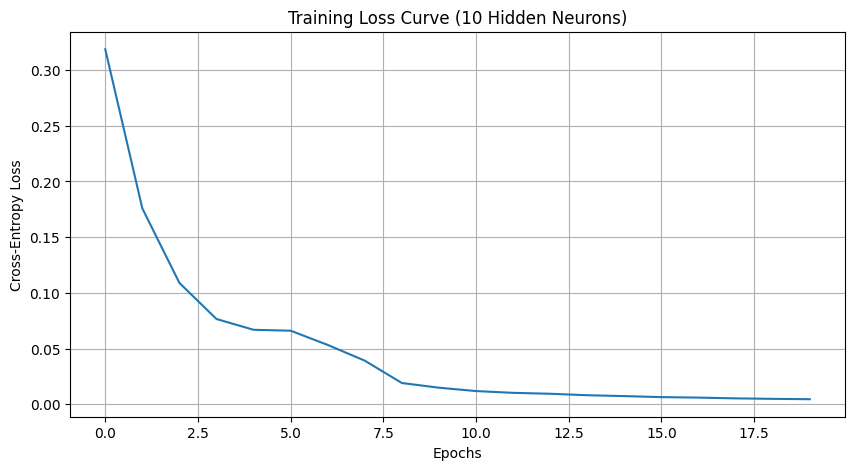


Training with 15 neurons in the hidden layer:
Epoch 5/20, Loss: 0.0937
Epoch 10/20, Loss: 0.1392
Epoch 15/20, Loss: 0.0179
Epoch 20/20, Loss: 0.0090


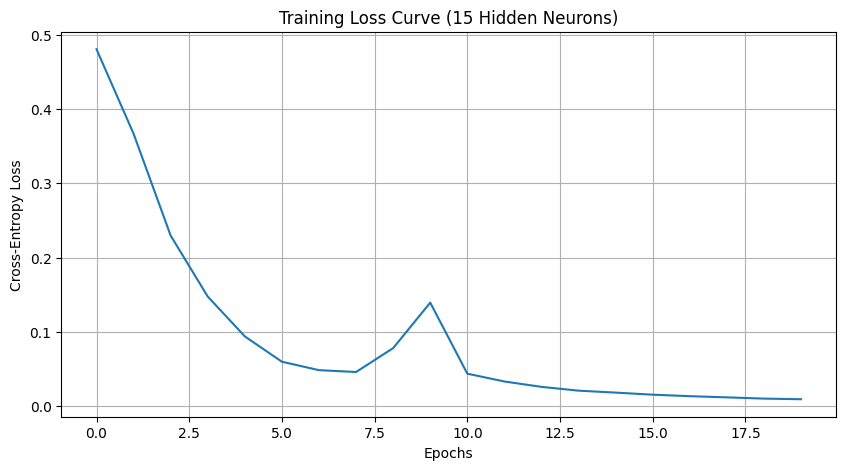


Training with 20 neurons in the hidden layer:
Epoch 5/20, Loss: 0.0758
Epoch 10/20, Loss: 0.0068
Epoch 15/20, Loss: 0.0039
Epoch 20/20, Loss: 0.0028


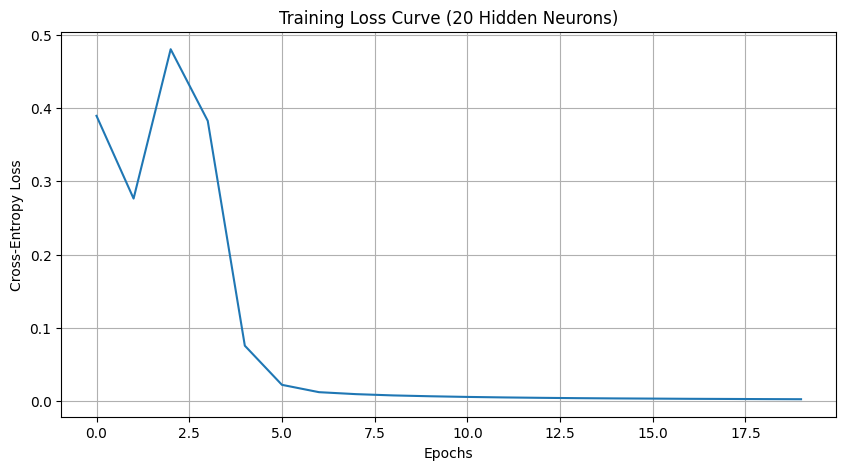


Training with 25 neurons in the hidden layer:
Epoch 5/20, Loss: 0.1891
Epoch 10/20, Loss: 0.0155
Epoch 15/20, Loss: 0.0073
Epoch 20/20, Loss: 0.0046


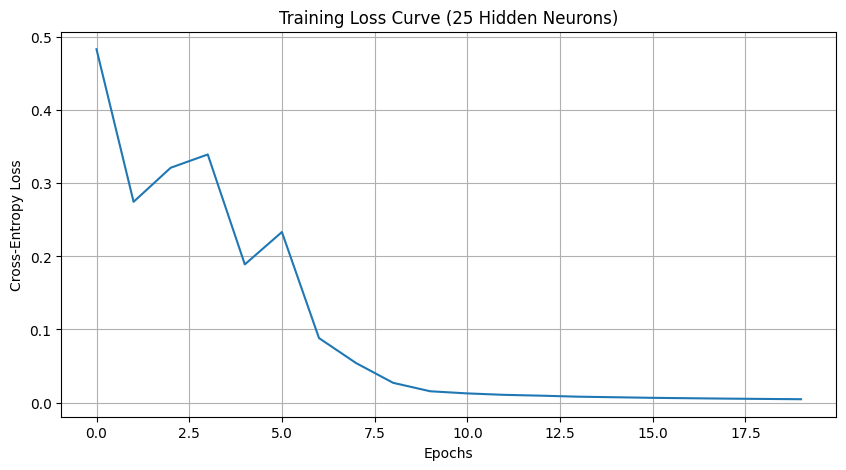


Training with 30 neurons in the hidden layer:
Epoch 5/20, Loss: 0.4181
Epoch 10/20, Loss: 0.0056
Epoch 15/20, Loss: 0.0024
Epoch 20/20, Loss: 0.0017


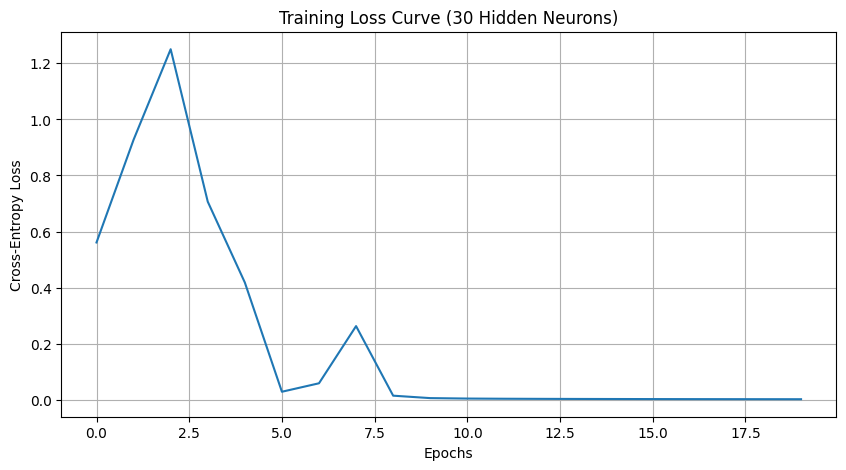

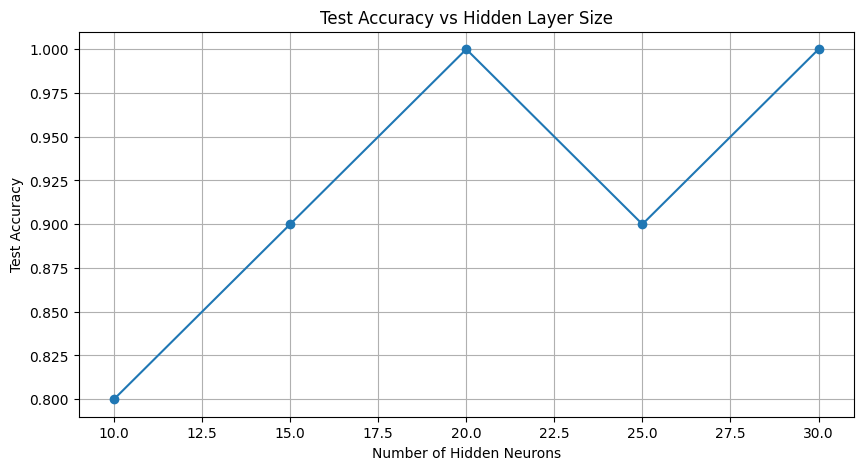

In [17]:
for neurons in hidden_neuron_options:
    print(f"\nTraining with {neurons} neurons in the hidden layer:")

    losses_recorded, train_acc_recorded, test_acc_recorded = train_and_evaluate_model(
                                                            X_training,
                                                            y_training,
                                                            X_testing,
                                                            y_testing,
                                                            neurons)

    performance_results.append({
                                'hidden_neurons': neurons,
                                'losses': losses_recorded,
                                'test_accuracy': test_acc_recorded})

    # Plot loss curve
    plt.figure(figsize=(10, 5))
    plt.plot(losses_recorded)
    plt.title(f'Training Loss Curve ({neurons} Hidden Neurons)')
    plt.xlabel('Epochs')
    plt.ylabel('Cross-Entropy Loss')
    plt.grid(True)
    plt.show()

# Plot test accuracy
plt.figure(figsize=(10, 5))
plt.plot([result['hidden_neurons'] for result in performance_results],
         [result['test_accuracy'] for result in performance_results],
         marker='o')
plt.title('Test Accuracy vs Hidden Layer Size')
plt.xlabel('Number of Hidden Neurons')
plt.ylabel('Test Accuracy')
plt.grid(True)
plt.show()


**SUMMARY**

Initially, with 10 hidden neurons, the test accuracy is approximately 80%. As the number of neurons increases to 15 and 20, the accuracy improves significantly, reaching a peak of 100% at 20 neurons. However, increasing the number of hidden neurons further to 25 results in a sharp drop in accuracy to around 90%. Finally, with 30 hidden neurons, the test accuracy recovers and again reaches 100%.